<a href="https://colab.research.google.com/github/rawalnidhi/IoT-Irrigation-Optimization-Research/blob/main/notebooks/smart_agriculture_visual_storytelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Agriculture Visual Storytelling

## MSDS670 — Data Visualization

### Author
Nidhi Rawal

---

## Project Overview

This project explores how environmental and irrigation conditions contribute to soil moisture variability in smart agriculture systems. The analysis focuses on creating clear and accessible visualizations that support agricultural monitoring and irrigation-related decision-making.

---

## Research Question

How do environmental and irrigation conditions influence soil moisture variability in smart agriculture systems?

In [8]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('smart_agriculture_cleaned.csv')

In [10]:
#Check Missing Values
print(df.isnull().sum())

farm_id                 0
region                  0
crop_type               0
soil_moisture_%         0
soil_pH                 0
temperature_C           0
rainfall_mm             0
humidity_%              0
sunlight_hours          0
irrigation_type         0
fertilizer_type         0
pesticide_usage_ml      0
sowing_date             0
harvest_date            0
total_days              0
yield_kg_per_hectare    0
sensor_id               0
timestamp               0
latitude                0
longitude               0
NDVI_index              0
crop_disease_status     0
month                   0
month_name              0
dtype: int64


# Final Visualizations and Analysis

The following visualizations explore environmental variability, irrigation methods, and soil moisture trends within smart agriculture systems. The goal of these visualizations is to communicate agricultural insights in a clear and accessible way for both technical and non-technical audiences.

# Visualization 1 — Average Soil Moisture Trends Across Months

This visualization explores how average soil moisture levels vary across different months. Monitoring soil moisture trends over time is important in smart agriculture because it helps identify seasonal variability and supports irrigation planning decisions.

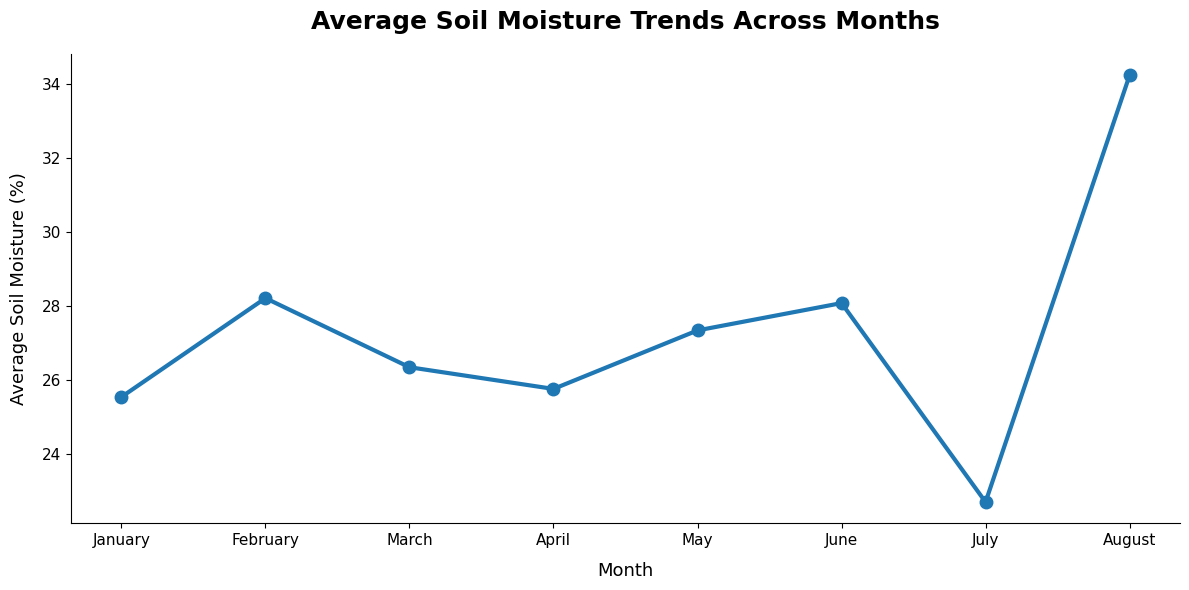

In [11]:

# Monthly average soil moisture
monthly_moisture = (
    df.groupby('month_name')['soil_moisture_%']
    .mean()
)

# Correct month order
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

monthly_moisture = monthly_moisture.reindex(month_order)
monthly_moisture = monthly_moisture.dropna()

plt.figure(figsize=(12,6))

plt.plot(
    monthly_moisture.index,
    monthly_moisture.values,
    linewidth=3,
    marker='o',
    markersize=9
)

plt.title(
    'Average Soil Moisture Trends Across Months',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.xlabel(
    'Month',
    fontsize=13,
    labelpad=10
)

plt.ylabel(
    'Average Soil Moisture (%)',
    fontsize=13,
    labelpad=10
)

# Remove top and right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improve tick readability
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig(
    'monthly_soil_moisture_trends.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Analysis

- Average soil moisture levels fluctuated across the available observation period, indicating environmental variability within the agricultural system.
- July showed relatively lower average soil moisture levels, while August displayed higher moisture levels.
- These variations highlight the importance of continuous environmental monitoring in smart agriculture systems to support irrigation planning and water management decisions.

# Visualization 2 — Average Soil Moisture by Irrigation Type

This visualization compares average soil moisture levels across different irrigation methods. Understanding how soil moisture varies between irrigation approaches can help support irrigation planning and agricultural monitoring practices.

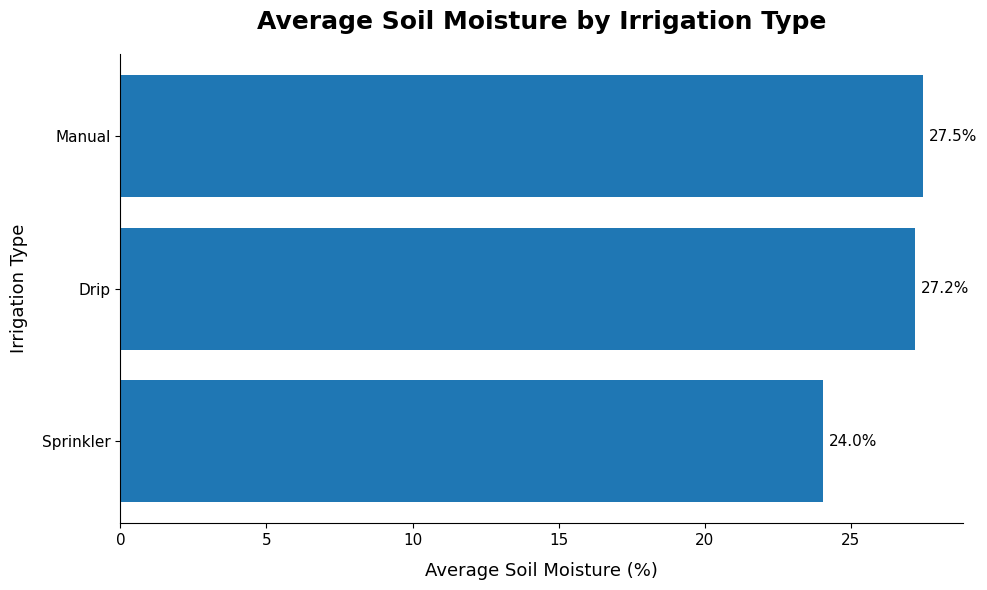

In [12]:
# Remove unknown irrigation values
irrigation_df = df[df['irrigation_type'] != 'Unknown']

# Calculate average soil moisture
avg_moisture = (
    irrigation_df.groupby('irrigation_type')['soil_moisture_%']
    .mean()
    .sort_values()
)

# Create figure
plt.figure(figsize=(10,6))

# Create horizontal bar chart
bars = plt.barh(
    avg_moisture.index,
    avg_moisture.values
)

# Title and labels
plt.title(
    'Average Soil Moisture by Irrigation Type',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.xlabel(
    'Average Soil Moisture (%)',
    fontsize=13,
    labelpad=10
)

plt.ylabel(
    'Irrigation Type',
    fontsize=13,
    labelpad=10
)

# Remove unnecessary borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add data labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        fontsize=11
    )

# Improve tick readability
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Remove grid clutter
plt.grid(False)

plt.tight_layout()
plt.savefig(
    'soil_moisture_by_irrigation_type.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Analysis

- Soil moisture levels varied slightly across irrigation methods within the dataset.
- Drip and manual irrigation methods showed relatively higher average soil moisture levels compared to sprinkler irrigation.
- While the differences were moderate, the visualization demonstrates how irrigation practices may contribute to variability in agricultural moisture conditions.

# Visualization 3 — Temperature and Soil Moisture Variability

This visualization explores the relationship between temperature and soil moisture levels within the agricultural dataset. While the dataset does not show a strong linear relationship, the scatterplot helps illustrate environmental variability across different agricultural conditions.

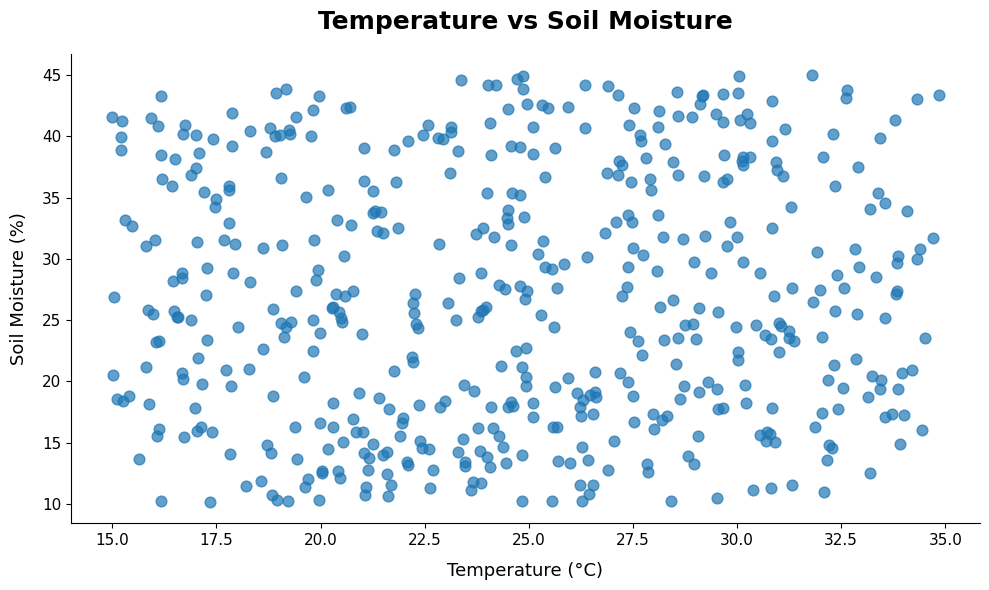

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['temperature_C'],
    df['soil_moisture_%'],
    alpha=0.7,
    s=60
)

plt.title(
    'Temperature vs Soil Moisture',
    fontsize=18,
    fontweight='bold',
    pad=18
)

plt.xlabel(
    'Temperature (°C)',
    fontsize=13,
    labelpad=10
)

plt.ylabel(
    'Soil Moisture (%)',
    fontsize=13,
    labelpad=10
)

# Remove unnecessary borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improve tick readability
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Remove grid clutter
plt.grid(False)

plt.tight_layout()
plt.savefig(
    'temperature_vs_soil_moisture.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Analysis

- The scatterplot shows considerable variability in soil moisture levels across different temperature conditions.
- No strong linear relationship was observed between temperature and soil moisture within the dataset.
- The visualization suggests that agricultural moisture conditions are likely influenced by multiple interacting environmental and irrigation-related factors rather than a single variable alone.

# Conclusion

This project explored environmental and irrigation-related variability within a smart agriculture dataset using data visualization techniques. While the dataset did not demonstrate strong linear relationships between environmental variables, the visualizations highlighted important variability in soil moisture trends, irrigation methods, and agricultural conditions.

The analysis demonstrated that agricultural monitoring systems benefit from continuous observation of multiple environmental factors rather than reliance on a single predictive variable. The project also emphasized the importance of clear and accessible visual storytelling for communicating agricultural insights to both technical and non-technical audiences.

Overall, the visualizations support the broader role of smart agriculture technologies in improving environmental awareness, irrigation planning, and data-driven agricultural decision-making.